<h3><b>Python Project</b></h3>

| Sr.No. | Name  | PRN No. |
| --- | --- | --- |
| 1 | Pranav Menon | 25070123085 |
| 2 | Rachit | 25070123088  |
| 3 | Madhur | 25070123070  |
| 4 | Maahi | 25070123069  |

<div style="text-align:center;">
    <h1><b>INDIAN AUTOMOBILE MARKET ANALYSIS</b></h1>
</div>
<hr>
<h3 align="center">A Comparative Analysis of the Indian Automobile Market</h3>

---

> **Datasets Used:**  `Maruti Suzuki.csv`  ·  `Mahindra.csv`  ·  `Hyundai.csv`
>
> **Scope:** Data Cleaning → Exploratory Analysis → 15 Comparative Graphs → ML Prediction (Random Forest)


<h3><b>🟩 Introduction To The Topic</b></h3>

The Indian automobile market is one of the fastest‑growing sectors, with brands like M**aruti Suzuki, Mahindra, and Hyundai** playing dominant roles. This project focuses on analyzing their sales data to uncover ***trends, patterns, and comparative insights***. By cleaning and structuring raw datasets, we aim to build a reliable foundation for deeper exploration and predictive modeling.

## ***<span style="color:violet;">◆</span> Section 1 — Data Preprocessing*** (Unit -2)
> Applied the **12-step cleaning pipeline** to all three datasets independently.

> ***Steps:***

**View → Info → Missing Check → Dedup → Drop NaN → Strip Column Names → Fix Month → Numeric Cast → Remove Invalid → Reset Index → Verify → Save**

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ============================================================
                       # MARUTI SUZUKI
# ============================================================
 # Step 1:Data collection:
ms = pd.read_csv("/content/Maruti Suzuki.csv")
print("Original Maruti Dataset:\n"); print(ms.head())

#Step 2: Data Understanding:
print("\nDataset Info:\n"); print(ms.info())

# Step 3: Missing values:
print("\nMissing Values:\n"); print(ms.isnull().sum())


ms = ms.drop_duplicates()


ms = ms.dropna()


ms.columns = ms.columns.str.strip()

# Step 4: Data Transformation:
ms['Month'] = pd.to_datetime(ms['Month'], errors='coerce')
ms['Month'] = ms['Month'].dt.strftime('%Y-%m')


for col in ['Engine_CC','Seating_Capacity','Ex_Showroom_Price_Lakh',
            'Units_Sold','Mileage_KMPL','Customer_Rating',
            'Annual_Service_Cost_INR','Safety_Rating_Stars']:
    if col in ms.columns:
        ms[col] = pd.to_numeric(ms[col], errors='coerce')


ms = ms.dropna()


ms = ms.reset_index(drop=True)


print("\nCleaned Maruti Dataset:\n"); print(ms.head())


ms.to_csv("cleaned_maruti_suzuki.csv", index=False)
print(" Maruti cleaning done!")


# ============================================================
                          # HYUNDAI
# ============================================================
  # Step 1: Data Collection:
hy = pd.read_csv("/content/Hyundai.csv")
print("\nOriginal Hyundai Dataset:\n"); print(hy.head())
# Step 2: Data Understanding:
print("\nDataset Info:\n"); print(hy.info())
# Step 3: Missing values:
print("\nMissing Values:\n"); print(hy.isnull().sum())

hy = hy.drop_duplicates()
hy = hy.dropna()
hy.columns = hy.columns.str.strip()
hy['Month'] = pd.to_datetime(hy['Month'], errors='coerce')
hy['Month'] = hy['Month'].dt.strftime('%Y-%m')

for col in ['Engine_CC','Seating_Capacity','Ex_Showroom_Price_Lakh',
            'Units_Sold','Revenue_Crores','Mileage_KMPL','Customer_Rating',
            'Annual_Service_Cost_INR','Warranty_Years','Safety_Rating_Stars']:
    if col in hy.columns:
        hy[col] = pd.to_numeric(hy[col], errors='coerce')

hy = hy.dropna()
hy = hy.reset_index(drop=True)

print("\nCleaned Hyundai Dataset:\n"); print(hy.head())
hy.to_csv("cleaned_hyundai_sales.csv", index=False)
print("Hyundai cleaning done!")


# ============================================================
                           # MAHINDRA
# ============================================================
 # step 1:Data Collection:
mh = pd.read_csv("/content/Mahindra.csv")
print("\nOriginal Mahindra Dataset:\n"); print(mh.head())
# Step 2: Data Transformation:
print("\nDataset Info:\n"); print(mh.info())
# Step 3: Missing values:
print("\nMissing Values:\n"); print(mh.isnull().sum())

mh = mh.drop_duplicates()
mh = mh.dropna()
mh.columns = mh.columns.str.strip()
mh['Month'] = pd.to_datetime(mh['Month'], errors='coerce')
mh['Month'] = mh['Month'].dt.strftime('%Y-%m')

for col in ['Engine_CC','Seating_Capacity','Ex_Showroom_Price_Lakh',
            'Units_Sold','Revenue_Crores','Mileage_KMPL','Customer_Rating',
            'Annual_Service_Cost_INR','Warranty_Years','Safety_Rating_Stars']:
    if col in mh.columns:
        mh[col] = pd.to_numeric(mh[col], errors='coerce')

mh = mh.dropna()
mh = mh.reset_index(drop=True)
# Step 9:Reportation and Documentation:
print("\nCleaned Mahindra Dataset:\n"); print(mh.head())
mh.to_csv("cleaned_mahindra_sales.csv", index=False)
print(" Mahindra cleaning done!")


# ============================================================
                     # COMBINED DATASET
# ============================================================
for df_temp, brand in zip([ms, mh, hy], ["Maruti", "Mahindra", "Hyundai"]):
    df_temp["Brand"] = brand
    df_temp["Month"] = pd.to_datetime(df_temp["Month"], format="%Y-%m", errors='coerce')


for col in ["Engine_CC", "Seating_Capacity", "Warranty_Years"]:
    if col not in ms.columns:
        ms[col] = np.nan

all_cols = ["Month","Brand","Car_Model","Segment","Fuel_Type","Transmission",
            "Engine_CC","Seating_Capacity","Ex_Showroom_Price_Lakh","Units_Sold",
            "Revenue_Crores","Mileage_KMPL","Customer_Rating",
            "Annual_Service_Cost_INR","Warranty_Years","Safety_Rating_Stars"]

df = pd.concat([ms[all_cols], mh[all_cols], hy[all_cols]], ignore_index=True)
df["Year"]     = df["Month"].dt.year
df["Quarter"]  = df["Month"].dt.quarter
df["MonthNum"] = df["Month"].dt.month
df["Price_Band"] = pd.cut(df["Ex_Showroom_Price_Lakh"],
                           bins=[0, 7, 15, 25, 100],
                           labels=["Budget (<7L)", "Mid (7-15L)", "Premium (15-25L)", "Luxury (25L+)"])

BRAND_COLORS = {"Maruti": "#00C9FF", "Mahindra": "#FF6B6B", "Hyundai": "#FFD93D"}
print(f"\n Combined dataset ready: {df.shape[0]} rows | Brands: {df.Brand.unique()}")

Original Maruti Dataset:

     Month Car_Model    Segment   Fuel_Type Transmission  \
0  2020-01  Alto K10  Hatchback      Petrol       Manual   
1  2020-01    Baleno  Hatchback      Petrol   Manual/AMT   
2  2020-01    Brezza        SUV  Petrol/CNG    Manual/AT   
3  2020-01   Celerio  Hatchback  Petrol/CNG   Manual/AMT   
4  2020-01      Ciaz      Sedan      Petrol       Manual   

   Ex_Showroom_Price_Lakh  Units_Sold  Revenue_Crores  Mileage_KMPL  \
0                    4.54      7623.0          346.08         24.54   
1                    7.61      7583.0          577.07         23.34   
2                    8.10      5743.0          465.18         19.40   
3                    5.28      8014.0          423.14         25.83   
4                    8.76      3898.0          341.46         20.43   

   Customer_Rating  Annual_Service_Cost_INR  Safety_Rating_Stars  
0              5.0                  12566.0                  3.0  
1              4.0                   8357.0         

## ***<span style="color:violet;">◆</span> Section 1.1 — Data Analysis*** (Unit -2) Step 7: Relationship Analysis:

In [ ]:
# ── UNIVARIATE ANALYSIS ───────────────────────────────────────────────────────
print("=" * 60)
print("UNIVARIATE ANALYSIS — Units Sold")
print("=" * 60)

col = 'Units_Sold'

print(f"\nMean   : {df[col].mean():.2f}")
print(f"Median : {df[col].median():.2f}")
print(f"Mode   : {df[col].mode()[0]}")
print(f"Std Dev: {df[col].std():.2f}")
print(f"Variance: {df[col].var():.2f}")
print(f"Min    : {df[col].min()}")
print(f"Max    : {df[col].max()}")

print(f"\n[Are there outliers?]")
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
print(f"Outliers found: {len(outliers)} records")

UNIVARIATE ANALYSIS — Units Sold

Mean   : 7186.19
Median : 7021.00
Mode   : 4472.0
Std Dev: 3551.55
Variance: 12613524.05
Min    : 400.0
Max    : 14992.0

[Are there outliers?]
Outliers found: 0 records


In [ ]:
# ── BIVARIATE ANALYSIS ────────────────────────────────────────────────────────
print("=" * 60)
print("BIVARIATE ANALYSIS — Correlation between Variables")
print("=" * 60)

# Pearson Correlation Coefficient
pairs = [
    ('Ex_Showroom_Price_Lakh', 'Units_Sold'),
    ('Mileage_KMPL',           'Customer_Rating'),
    ('Customer_Rating',        'Units_Sold'),
    ('Annual_Service_Cost_INR','Units_Sold'),
]

for col1, col2 in pairs:
    r = df[col1].corr(df[col2])
    print(f"  {col1} vs {col2:30} → Pearson r = {r:.3f}")

# Cross-tabulation (Categorical × Categorical)
print("\n[Cross-Tabulation] Brand vs Transmission:")
print(pd.crosstab(df['Brand'], df['Transmission']))

print("\n[Cross-Tabulation] Brand vs Fuel_Type:")
print(pd.crosstab(df['Brand'], df['Fuel_Type']))

BIVARIATE ANALYSIS — Correlation between Variables
  Ex_Showroom_Price_Lakh vs Units_Sold                     → Pearson r = -0.007
  Mileage_KMPL vs Customer_Rating                → Pearson r = 0.138
  Customer_Rating vs Units_Sold                     → Pearson r = -0.010
  Annual_Service_Cost_INR vs Units_Sold                     → Pearson r = -0.047

[Cross-Tabulation] Brand vs Transmission:
Transmission  Automatic  Manual  Manual/AMT  Manual/AMT/AT  Manual/AT
Brand                                                                
Hyundai             379     374           0              0          0
Mahindra            350     405           0              0          0
Maruti                0     150         298             54        194

[Cross-Tabulation] Brand vs Fuel_Type:
Fuel_Type  Diesel  Petrol  Petrol/CNG  Petrol/Strong Hybrid
Brand                                                      
Hyundai       365     388           0                     0
Mahindra      398     357        

In [ ]:
# ── MULTIVARIATE ANALYSIS ─────────────────────────────────────────────────────
print("=" * 60)
print("MULTIVARIATE ANALYSIS — Correlation Matrix")
print("=" * 60)

num_cols = ['Ex_Showroom_Price_Lakh', 'Units_Sold', 'Mileage_KMPL',
            'Customer_Rating', 'Safety_Rating_Stars', 'Revenue_Crores']

corr_matrix = df[num_cols].corr().round(3)
print(corr_matrix)

# Covariance Matrix
print("\n[Covariance Matrix]")
print(df[num_cols].cov().round(2))

MULTIVARIATE ANALYSIS — Correlation Matrix


NameError: name 'df' is not defined

In [ ]:
# ── DATA TYPES CLASSIFICATION ─────────────────────────────────────────────────
print("=" * 60)
print("DATA TYPES IN OUR DATASET")
print("=" * 60)

type_map = {
    'Car_Model'               : 'Qualitative — Nominal   (No order, named categories)',
    'Brand'                   : 'Qualitative — Nominal   (No order, named categories)',
    'Fuel_Type'               : 'Qualitative — Nominal   (No order, named categories)',
    'Transmission'            : 'Qualitative — Nominal   (No order, named categories)',
    'Segment'                 : 'Qualitative — Ordinal   (Ordered: Budget→Luxury)',
    'Safety_Rating_Stars'     : 'Quantitative — Discrete (Whole numbers: 1–5 stars)',
    'Seating_Capacity'        : 'Quantitative — Discrete (Whole numbers, countable)',
    'Units_Sold'              : 'Quantitative — Discrete (Count, no fractions)',
    'Ex_Showroom_Price_Lakh'  : 'Quantitative — Continuous (Decimal values)',
    'Mileage_KMPL'            : 'Quantitative — Continuous (Decimal values)',
    'Customer_Rating'         : 'Quantitative — Continuous (Interval Scale)',
    'Revenue_Crores'          : 'Quantitative — Continuous (Ratio Scale, true zero)',
    'Month'                   : 'Quantitative — Interval  (Date/Time, no true zero)',
}

for col, dtype in type_map.items():
    print(f"  {col:<30} → {dtype}")

# Verify using pandas dtypes
print("\n[Pandas dtype verification]")
print(df[list(type_map.keys())].dtypes)

DATA TYPES IN OUR DATASET
  Car_Model                      → Qualitative — Nominal   (No order, named categories)
  Brand                          → Qualitative — Nominal   (No order, named categories)
  Fuel_Type                      → Qualitative — Nominal   (No order, named categories)
  Transmission                   → Qualitative — Nominal   (No order, named categories)
  Segment                        → Qualitative — Ordinal   (Ordered: Budget→Luxury)
  Safety_Rating_Stars            → Quantitative — Discrete (Whole numbers: 1–5 stars)
  Seating_Capacity               → Quantitative — Discrete (Whole numbers, countable)
  Units_Sold                     → Quantitative — Discrete (Count, no fractions)
  Ex_Showroom_Price_Lakh         → Quantitative — Continuous (Decimal values)
  Mileage_KMPL                   → Quantitative — Continuous (Decimal values)
  Customer_Rating                → Quantitative — Continuous (Interval Scale)
  Revenue_Crores                 → Quantitative — C

---
##  ***<span style="color:violet;">◆</span> Section 2 — Exploratory Data Analysis*** (Unit - 3 and Unit - 4)
# Step 6: Data Visualization:
> Each graph is labelled with its **parameters**, **dataset source**, and **purpose**.
> Brand colour key:

| Brand | Color  | Logo |
| --- | --- | --- |
| Maruti | Blue | 🟦 |
| Mahindra | Red | 🟥 |
| Hyundai | Yellow | 🟨 |

In [ ]:
# ── DATA NORMALIZATION ────────────────────────────────────────────────────────
print("=" * 60)
print("DATA NORMALIZATION")
print("=" * 60)

from sklearn.preprocessing import MinMaxScaler, StandardScaler

col = 'Ex_Showroom_Price_Lakh'
data_col = df[[col]].dropna()

# 1. Min-Max Normalization (scales to 0–1)
min_max = MinMaxScaler()
df_minmax = min_max.fit_transform(data_col)
print(f"\n[Min-Max Normalization] — {col}")
print(f"  Original → Min: {data_col[col].min():.2f}, Max: {data_col[col].max():.2f}")
print(f"  Normalized → Min: {df_minmax.min():.2f}, Max: {df_minmax.max():.2f}")

# 2. Z-Score Normalization / Standardization (mean=0, std=1)
std_scaler = StandardScaler()
df_zscore = std_scaler.fit_transform(data_col)
print(f"\n[Z-Score Normalization] — {col}")
print(f"  Mean after scaling : {df_zscore.mean():.4f}  (should be ~0)")
print(f"  Std  after scaling : {df_zscore.std():.4f}  (should be ~1)")

# Manual Z-Score
mean = data_col[col].mean()
std  = data_col[col].std()
df['Price_ZScore'] = (df[col] - mean) / std
print(f"\n[Manual Z-Score] First 5 values:")
print(df['Price_ZScore'].dropna().head())

# 3. Decimal Scaling
import math
max_val = data_col[col].abs().max()
j = math.ceil(math.log10(max_val + 1))
df['Price_DecimalScaled'] = df[col] / (10 ** j)
print(f"\n[Decimal Scaling] Dividing by 10^{j} = {10**j}")
print(df['Price_DecimalScaled'].dropna().head())

DATA NORMALIZATION

[Min-Max Normalization] — Ex_Showroom_Price_Lakh
  Original → Min: 3.71, Max: 25.00
  Normalized → Min: 0.00, Max: 1.00

[Z-Score Normalization] — Ex_Showroom_Price_Lakh
  Mean after scaling : 0.0000  (should be ~0)
  Std  after scaling : 1.0000  (should be ~1)

[Manual Z-Score] First 5 values:
0   -1.469632
1   -0.940435
2   -0.855971
3   -1.342073
4   -0.742202
Name: Price_ZScore, dtype: float64

[Decimal Scaling] Dividing by 10^2 = 100
0    0.0454
1    0.0761
2    0.0810
3    0.0528
4    0.0876
Name: Price_DecimalScaled, dtype: float64


In [ ]:
# ── DATA BINNING ──────────────────────────────────────────────────────────────
print("=" * 60)
print("DATA BINNING — Continuous → Categorical Groups")
print("=" * 60)

# Equal-width binning using pd.cut()
df['Price_Bin'] = pd.cut(
    df['Ex_Showroom_Price_Lakh'],
    bins=[0, 7, 15, 25, 100],
    labels=['Budget (<7L)', 'Mid (7–15L)', 'Premium (15–25L)', 'Luxury (25L+)']
)
print("\n[pd.cut()] Price Binning — Equal Width:")
print(df['Price_Bin'].value_counts())

# Equal-frequency binning using pd.qcut()
df['Mileage_Bin'] = pd.qcut(
    df['Mileage_KMPL'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)
print("\n[pd.qcut()] Mileage Binning — Equal Frequency (Quartile-based):")
print(df['Mileage_Bin'].value_counts())

# Custom bin for Customer Rating
df['Rating_Bin'] = pd.cut(
    df['Customer_Rating'],
    bins=[0, 2, 3.5, 4.5, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)
print("\n[pd.cut()] Customer Rating Binning:")
print(df['Rating_Bin'].value_counts())

DATA BINNING — Continuous → Categorical Groups

[pd.cut()] Price Binning — Equal Width:
Price_Bin
Mid (7–15L)         1093
Premium (15–25L)     762
Budget (<7L)         349
Luxury (25L+)          0
Name: count, dtype: int64

[pd.qcut()] Mileage Binning — Equal Frequency (Quartile-based):
Mileage_Bin
Medium       557
Low          551
High         548
Very High    548
Name: count, dtype: int64

[pd.cut()] Customer Rating Binning:
Rating_Bin
Good         1721
Excellent     408
Average        75
Poor            0
Name: count, dtype: int64


In [ ]:
# ── CATEGORICAL ENCODING ──────────────────────────────────────────────────────
print("=" * 60)
print("TURNING CATEGORICAL VARIABLES INTO QUANTITATIVE")
print("=" * 60)

from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding — assigns a unique integer to each category
le = LabelEncoder()
df['Brand_Encoded'] = le.fit_transform(df['Brand'])
print("\n[Label Encoding] Brand:")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} → {code}")

df['Fuel_Encoded'] = le.fit_transform(df['Fuel_Type'])
print("\n[Label Encoding] Fuel_Type:")
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {label} → {code}")

# 2. One-Hot Encoding — creates separate binary columns per category
df_onehot = pd.get_dummies(df['Segment'], prefix='Segment')
print("\n[One-Hot Encoding] Segment:")
print(df_onehot.head(3))

# 3. Dummy Encoding — same as one-hot but drops first column (avoids redundancy)
df_dummy = pd.get_dummies(df['Transmission'], drop_first=True, prefix='Trans')
print("\n[Dummy Encoding] Transmission (drop_first=True):")
print(df_dummy.head(3))

TURNING CATEGORICAL VARIABLES INTO QUANTITATIVE

[Label Encoding] Brand:
  Hyundai → 0
  Mahindra → 1
  Maruti → 2

[Label Encoding] Fuel_Type:
  Diesel → 0
  Petrol → 1
  Petrol/CNG → 2
  Petrol/Strong Hybrid → 3

[One-Hot Encoding] Segment:
   Segment_Hatchback  Segment_MPV  Segment_SUV  Segment_Sedan
0               True        False        False          False
1               True        False        False          False
2              False        False         True          False

[Dummy Encoding] Transmission (drop_first=True):
   Trans_Manual  Trans_Manual/AMT  Trans_Manual/AMT/AT  Trans_Manual/AT
0          True             False                False            False
1         False              True                False            False
2         False             False                False             True


### 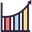***Graph 1 — Spread & Outliers by Brand (Boxplots)***

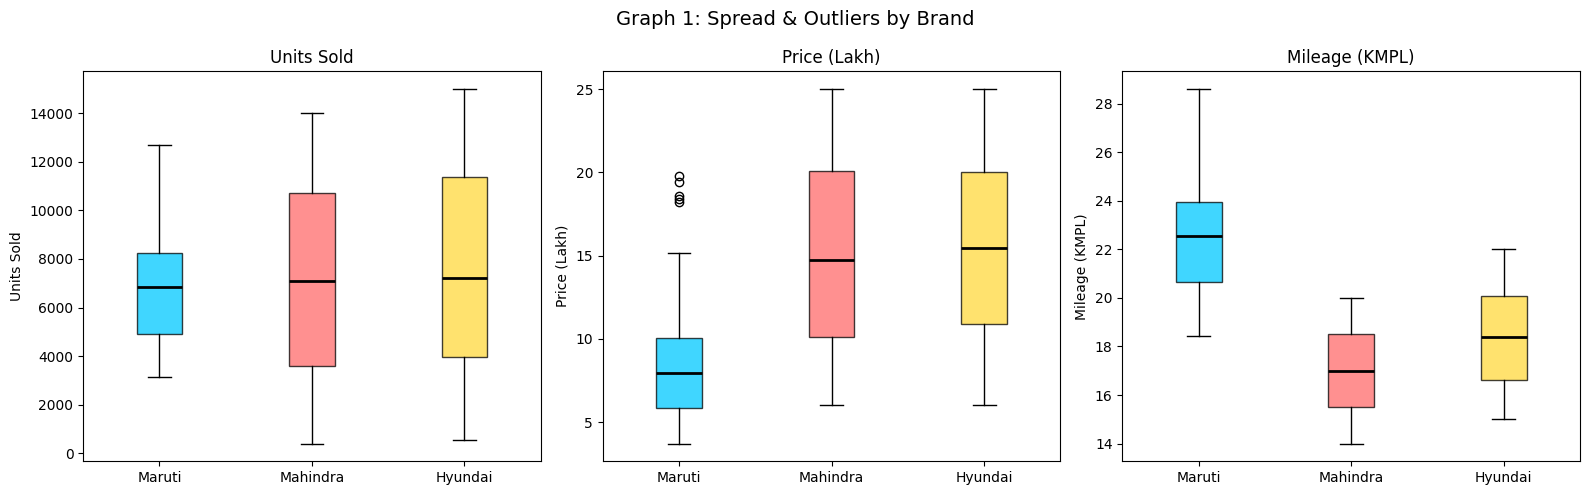

In [ ]:
# GRAPH 1 — Boxplots by Brand (Units Sold | Ex_Showroom_Price_Lakh | Mileage_KMPL)
# Dataset: Maruti + Mahindra + Hyundai

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Graph 1: Spread & Outliers by Brand", fontsize=14)

for ax, (col, label) in zip(axes, [
    ("Units_Sold",             "Units Sold"),
    ("Ex_Showroom_Price_Lakh", "Price (Lakh)"),
    ("Mileage_KMPL",           "Mileage (KMPL)")
]):
    data = [df[df["Brand"]==b][col].dropna() for b in ["Maruti","Mahindra","Hyundai"]]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], BRAND_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(["Maruti","Mahindra","Hyundai"])
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### 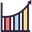***Graph 2 — Correlation Heatmap***
`Parameters:` Price · Units Sold · Revenue · Mileage · Customer Rating · Annual Service Cost

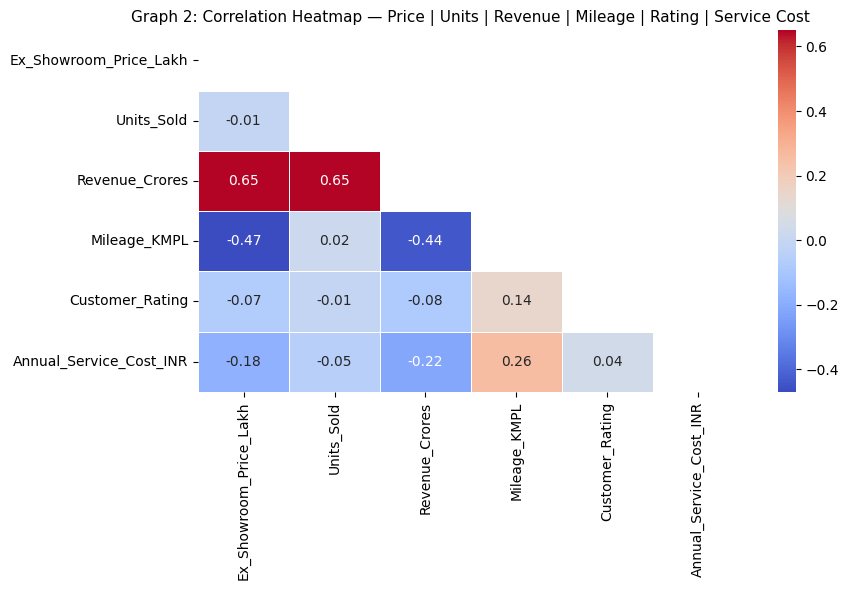

In [ ]:
# GRAPH 2 — Correlation Heatmap
# Parameters: Price | Units Sold | Revenue | Mileage | Customer Rating | Service Cost
# Dataset: Maruti + Mahindra + Hyundai

num_cols = ["Ex_Showroom_Price_Lakh","Units_Sold","Revenue_Crores",
            "Mileage_KMPL","Customer_Rating","Annual_Service_Cost_INR"]

corr = df[num_cols].corr().round(2)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title("Graph 2: Correlation Heatmap — Price | Units | Revenue | Mileage | Rating | Service Cost", fontsize=11)
plt.tight_layout()
plt.show()

### 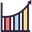***Graph 3 — Total Units Sold by Segment & Brand***
`Parameters:` Segment · Units_Sold · Brand

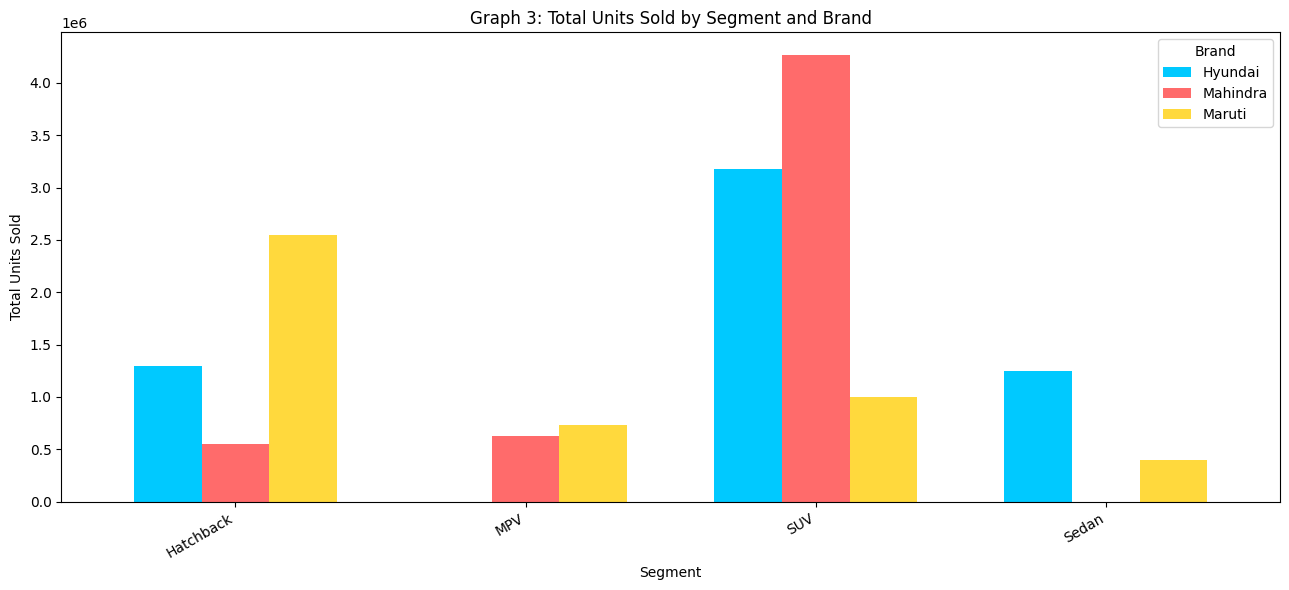

In [ ]:
# GRAPH 3 — Units_Sold by Brand × Segment (Grouped Bar)
# Dataset: Maruti + Mahindra + Hyundai

seg_brand = df.groupby(["Segment","Brand"])["Units_Sold"].sum().unstack(fill_value=0)

seg_brand.plot(kind="bar", figsize=(13, 6),
               color=list(BRAND_COLORS.values()), width=0.7)
plt.title("Graph 3: Total Units Sold by Segment and Brand")
plt.xlabel("Segment")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

### 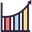***Graph 4 — Monthly Units Sold Trend (2020–2024)***
`Parameters:` Month · Units_Sold · Brand

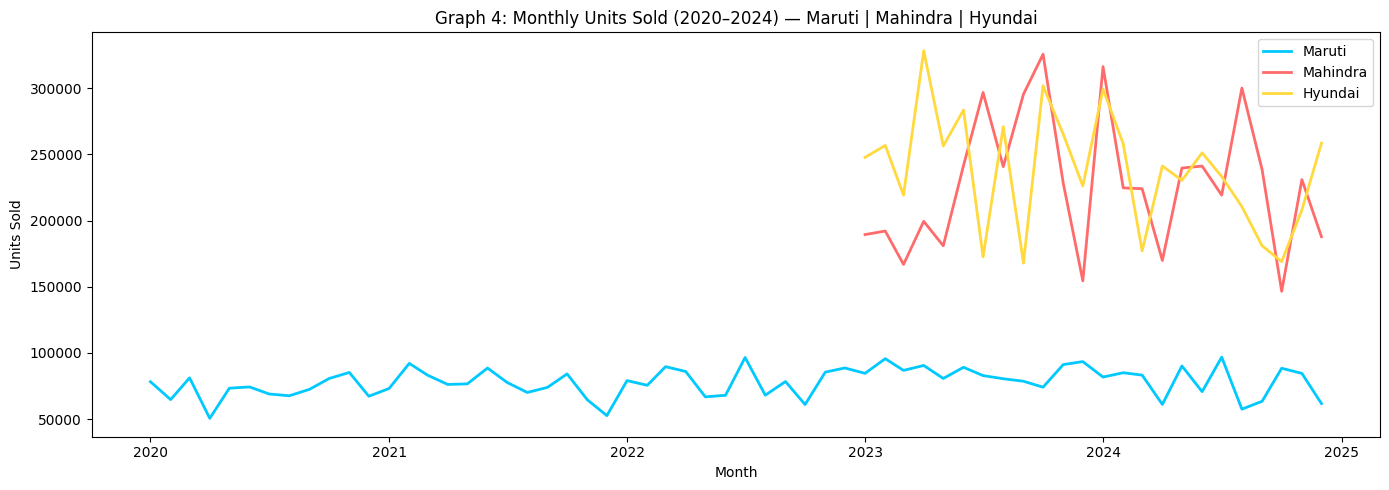

In [ ]:
# GRAPH 4 — Monthly Units_Sold trend by Brand (Line)
# Dataset: Maruti + Mahindra + Hyundai

monthly = df.groupby(["Month","Brand"])["Units_Sold"].sum().reset_index()

plt.figure(figsize=(14, 5))
for brand, color in BRAND_COLORS.items():
    sub = monthly[monthly["Brand"]==brand]
    plt.plot(sub["Month"], sub["Units_Sold"], color=color, label=brand, linewidth=2)

plt.title("Graph 4: Monthly Units Sold (2020–2024) — Maruti | Mahindra | Hyundai")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

### 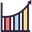***Graph 5 — Annual Revenue by Brand***
`Parameters:` Year · Revenue_Crores · Brand

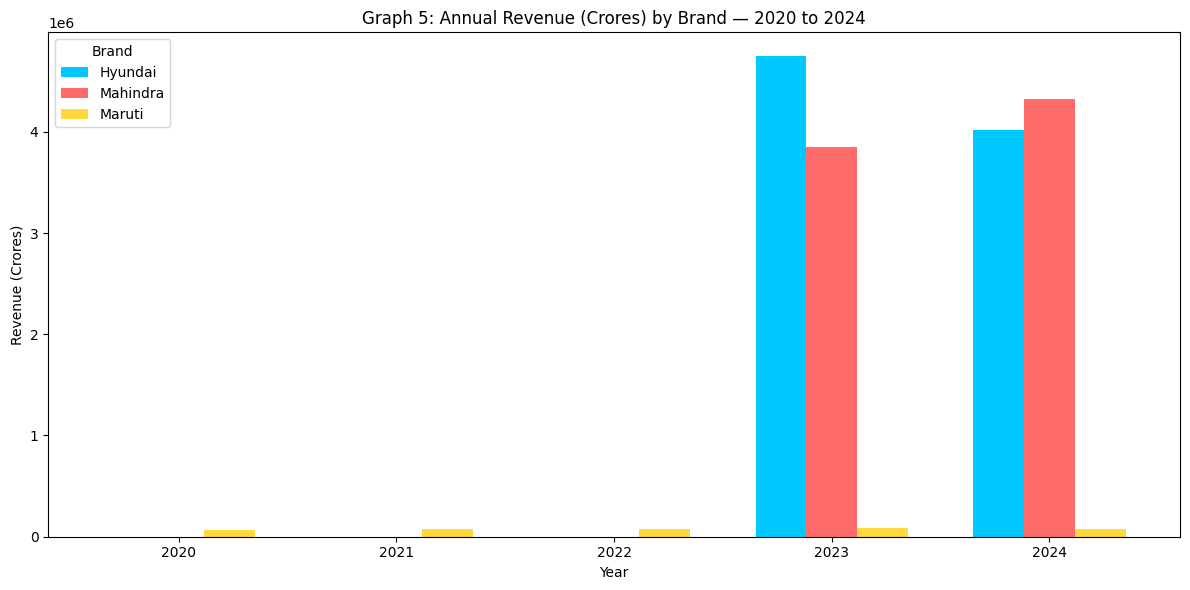

In [ ]:
# GRAPH 5 — Annual Revenue_Crores by Brand per Year (Grouped Bar)
# Dataset: Maruti + Mahindra + Hyundai

yearly = df.groupby(["Year","Brand"])["Revenue_Crores"].sum().unstack(fill_value=0)

yearly.plot(kind="bar", figsize=(12, 6),
            color=list(BRAND_COLORS.values()), width=0.7)
plt.title("Graph 5: Annual Revenue (Crores) by Brand — 2020 to 2024")
plt.xlabel("Year")
plt.ylabel("Revenue (Crores)")
plt.xticks(rotation=0)
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

### 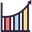***Graph 6 — Fuel Type Mix Over Years***
`Parameters:` Year · Fuel_Type · Units_Sold

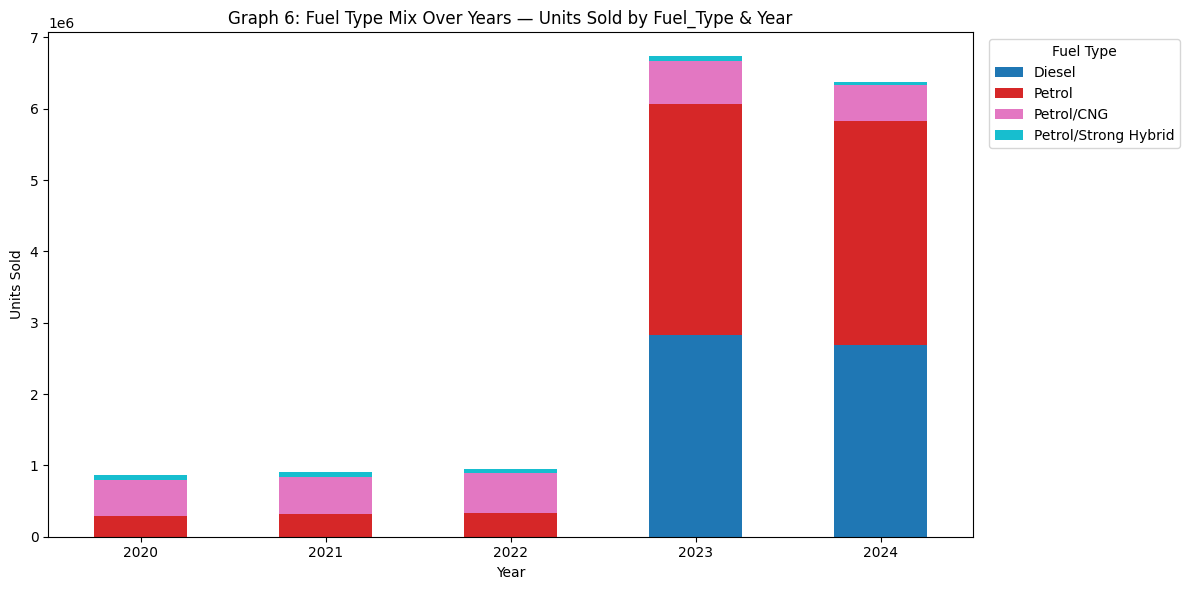

In [ ]:
# GRAPH 6 — Units_Sold by Fuel_Type stacked per Year
# Dataset: Maruti + Mahindra + Hyundai

fuel_yr = df.groupby(["Year","Fuel_Type"])["Units_Sold"].sum().unstack(fill_value=0)

fuel_yr.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab10")
plt.title("Graph 6: Fuel Type Mix Over Years — Units Sold by Fuel_Type & Year")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.legend(title="Fuel Type", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### 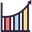***Graph 7 — Mileage vs Annual Service Cost (Bubble)***
`Parameters:` Mileage_KMPL · Annual_Service_Cost_INR · Units_Sold (bubble size)

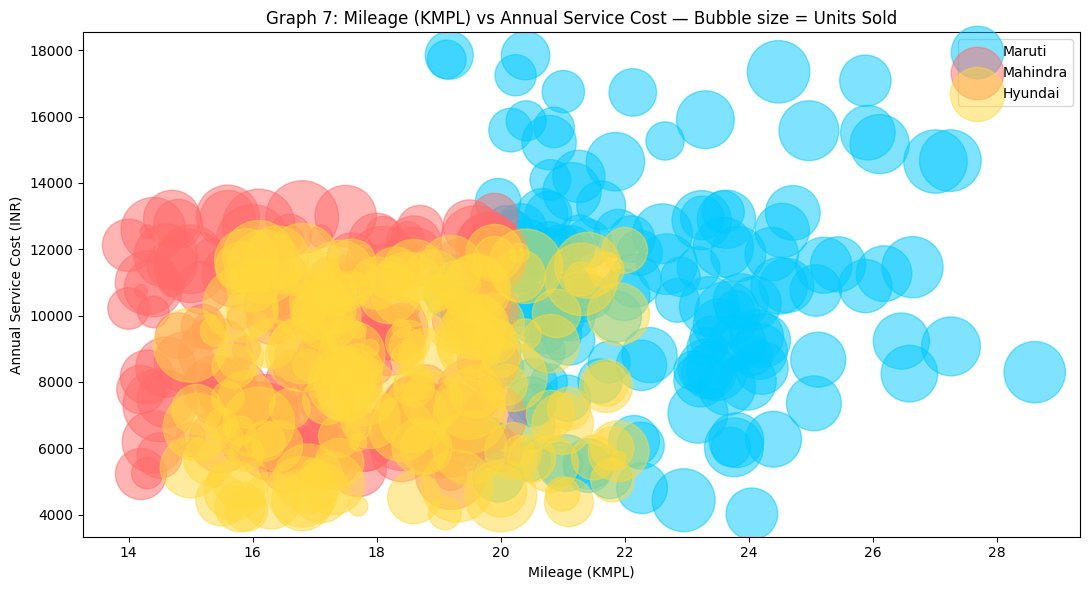

In [ ]:
# GRAPH 7 — Mileage_KMPL vs Annual_Service_Cost_INR, size = Units_Sold
# Dataset: Maruti + Mahindra + Hyundai

plt.figure(figsize=(11, 6))
for brand, color in BRAND_COLORS.items():
    sub = df[df["Brand"]==brand].sample(min(150, len(df[df["Brand"]==brand])), random_state=1)
    plt.scatter(sub["Mileage_KMPL"], sub["Annual_Service_Cost_INR"],
                s=sub["Units_Sold"]/5, color=color, alpha=0.5, label=brand)

plt.xlabel("Mileage (KMPL)")
plt.ylabel("Annual Service Cost (INR)")
plt.title("Graph 7: Mileage (KMPL) vs Annual Service Cost — Bubble size = Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

### 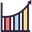***Graph 8 — Units Sold by Transmission Type & Brand***
`Parameters:` Brand · Transmission · Units_Sold

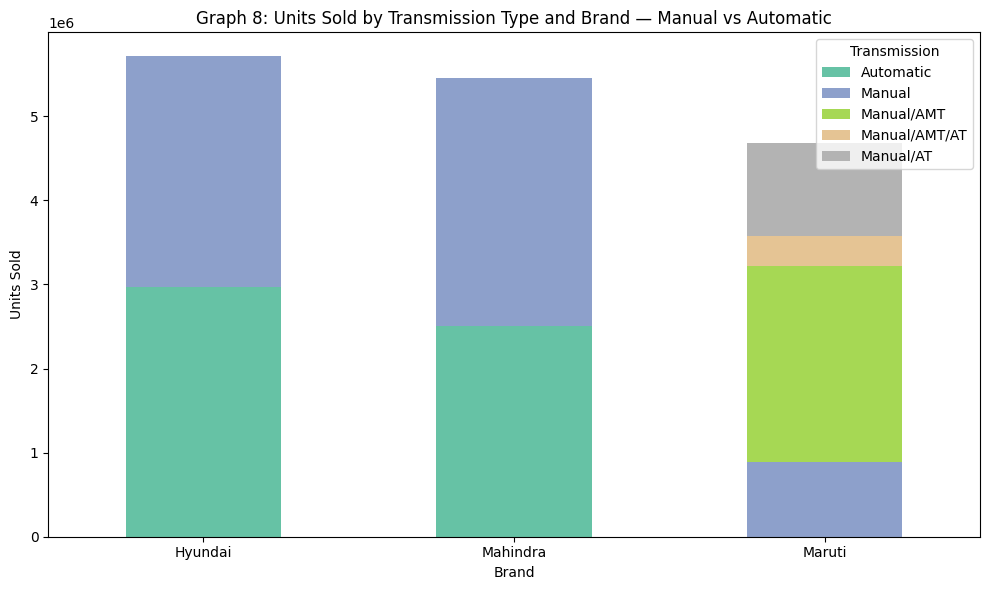

In [ ]:
# GRAPH 8 — Units_Sold by Transmission and Brand (Stacked Bar)
# Dataset: Maruti + Mahindra + Hyundai

trans_brand = df.groupby(["Brand","Transmission"])["Units_Sold"].sum().unstack(fill_value=0)

trans_brand.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Graph 8: Units Sold by Transmission Type and Brand — Manual vs Automatic")
plt.xlabel("Brand")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()

### 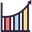***Graph 9 — Safety Rating Stars Distribution***
`Parameters:` Brand · Safety_Rating_Stars · Record Count

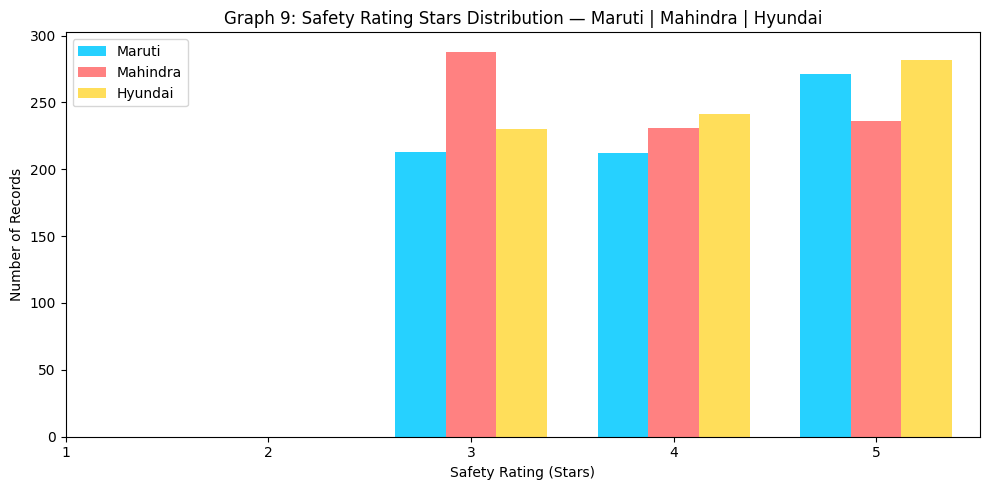

In [ ]:
# GRAPH 9 — Safety_Rating_Stars distribution count by Brand (Grouped Bar)
# Dataset: Maruti + Mahindra + Hyundai

safety_pivot = df.groupby(["Brand","Safety_Rating_Stars"]).size().reset_index(name="Count")

plt.figure(figsize=(10, 5))
for i, (brand, color) in enumerate(BRAND_COLORS.items()):
    sub = safety_pivot[safety_pivot["Brand"]==brand]
    plt.bar(sub["Safety_Rating_Stars"] + i*0.25 - 0.25,
            sub["Count"], width=0.25, color=color, label=brand, alpha=0.85)

plt.xlabel("Safety Rating (Stars)")
plt.ylabel("Number of Records")
plt.title("Graph 9: Safety Rating Stars Distribution — Maruti | Mahindra | Hyundai")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.tight_layout()
plt.show()

### 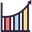***Graph 10 — Price Band vs Average Customer Rating***
`Parameters:` Price_Band · Customer_Rating · Brand

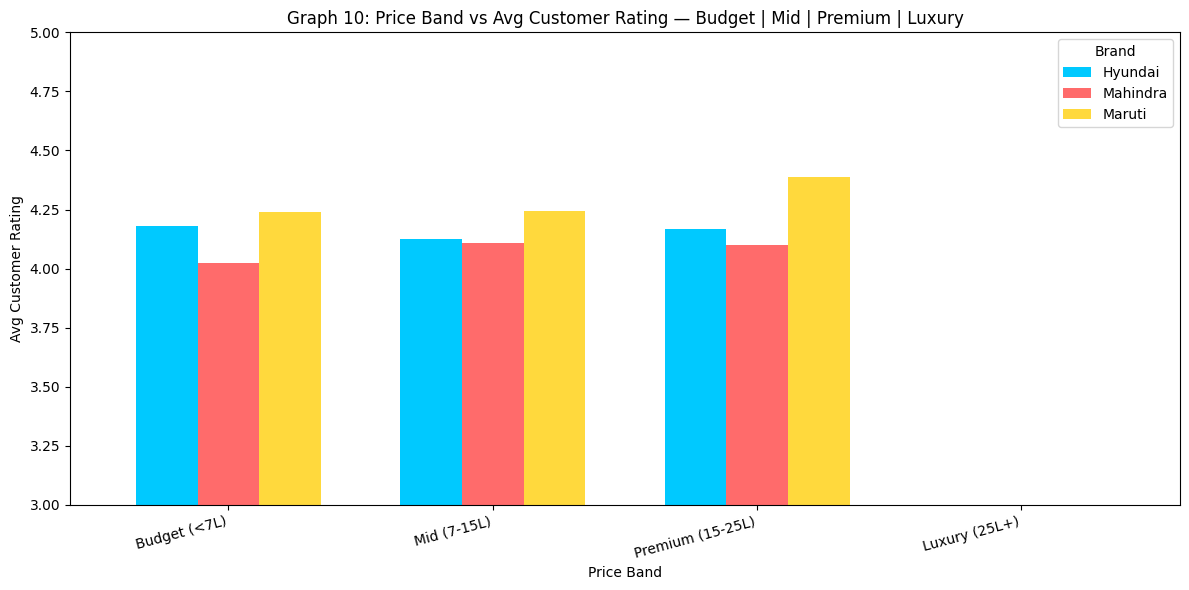

In [ ]:
# GRAPH 10 — Price_Band vs Avg Customer_Rating by Brand (Grouped Bar)
# Dataset: Maruti + Mahindra + Hyundai

pb_rating = df.groupby(["Price_Band","Brand"])["Customer_Rating"].mean().unstack(fill_value=0)

pb_rating.plot(kind="bar", figsize=(12, 6),
               color=list(BRAND_COLORS.values()), width=0.7)
plt.title("Graph 10: Price Band vs Avg Customer Rating — Budget | Mid | Premium | Luxury")
plt.xlabel("Price Band")
plt.ylabel("Avg Customer Rating")
plt.xticks(rotation=15, ha="right")
plt.ylim(3, 5)
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

<h3><b>🟩 Introduction To The Machine Learning</b></h3>

Machine Learning (ML) enables us to move beyond descriptive statistics into ***predictive intelligence***. In this project, we employ ***Random Forest, a robust ensemble learning algorithm, to forecast future sales trends***. Random Forest is particularly effective because it ***reduces overfitting***, handles complex relationships between variables and provides interpretable feature importance. This allows us to not only predict outcomes but also understand the ***key drivers behind automobile sales***.

---
##  ***<span style="color:violet;">◆</span> Section 3 — Machine Learning :  Predictor***
### Model: Random Forest Regressor (scikit-learn)

| Item | Detail |
|------|--------|
| **Target Variable** | `Units_Sold` |
| **Algorithm** | `RandomForestRegressor` — ensemble of 150 decision trees |
| **Train / Test Split** | 80% training · 20% testing (`random_state=42`) |
| **Evaluation Metrics** | R² Score · RMSE · MAE |

**Features Used:** Brand · Segment · Fuel Type · Transmission · Price · Mileage · Rating · Service Cost · Safety Stars · Year · Month · Quarter

In [ ]:
# ML — Random Forest Predictor for Units_Sold
# Features: Price, Mileage, Rating, Service Cost, Safety, Brand, Segment, Fuel, Transmission, Year, Month, Quarter
# Dataset: Maruti + Mahindra + Hyundai

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prepare ML dataframe
ml_df = df.dropna(subset=["Units_Sold","Ex_Showroom_Price_Lakh","Mileage_KMPL",
                           "Customer_Rating","Annual_Service_Cost_INR",
                           "Safety_Rating_Stars"]).copy()

# Encode categorical columns
for col in ["Brand","Segment","Fuel_Type","Transmission"]:
    le = LabelEncoder()
    ml_df[col+"_Enc"] = le.fit_transform(ml_df[col])

FEATURES = ["Brand_Enc","Segment_Enc","Fuel_Type_Enc","Transmission_Enc",
            "Ex_Showroom_Price_Lakh","Mileage_KMPL","Customer_Rating",
            "Annual_Service_Cost_INR","Safety_Rating_Stars",
            "Year","MonthNum","Quarter"]

X = ml_df[FEATURES]
y = ml_df["Units_Sold"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
r2   = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)

print(f"R² Score : {r2:.3f}")
print(f"RMSE     : {rmse:.1f} units")
print(f"MAE      : {mae:.1f} units")

R² Score : 0.015
RMSE     : 3397.7 units
MAE      : 2561.4 units


### ML Graph A — Feature Importance
`What:` Horizontal bar chart of each feature's contribution to prediction accuracy.

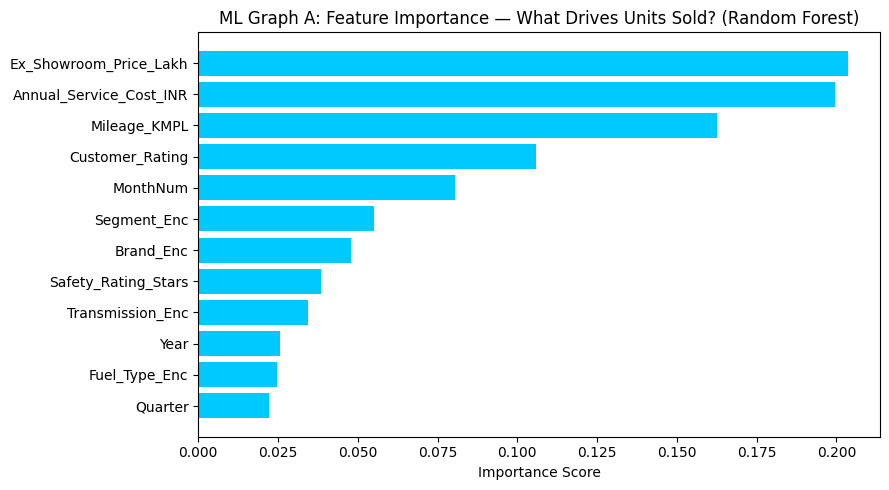

In [ ]:
# ML Graph A — Feature Importance: What Drives Units_Sold?

fi = pd.DataFrame({"Feature": FEATURES,
                   "Importance": rf.feature_importances_}).sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(fi["Feature"], fi["Importance"], color="#00C9FF")
plt.title("ML Graph A: Feature Importance — What Drives Units Sold? (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### ML Graph B — Actual vs Predicted Units Sold
`What:` Scatter plot comparing true values against model predictions. Perfect model = all points on the red dashed line.

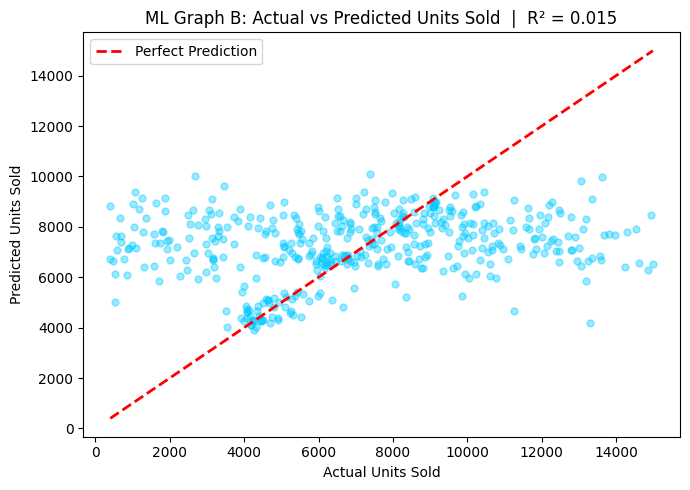

In [ ]:
# ML Graph B — Actual vs Predicted Units_Sold (Scatter)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, preds, alpha=0.4, color="#00C9FF", s=25)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title(f"ML Graph B: Actual vs Predicted Units Sold  |  R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

### ML Graph C — Residuals & Error Distribution
`What:` Left — residuals vs predicted (checks for bias). Right — error histogram (checks for normality).

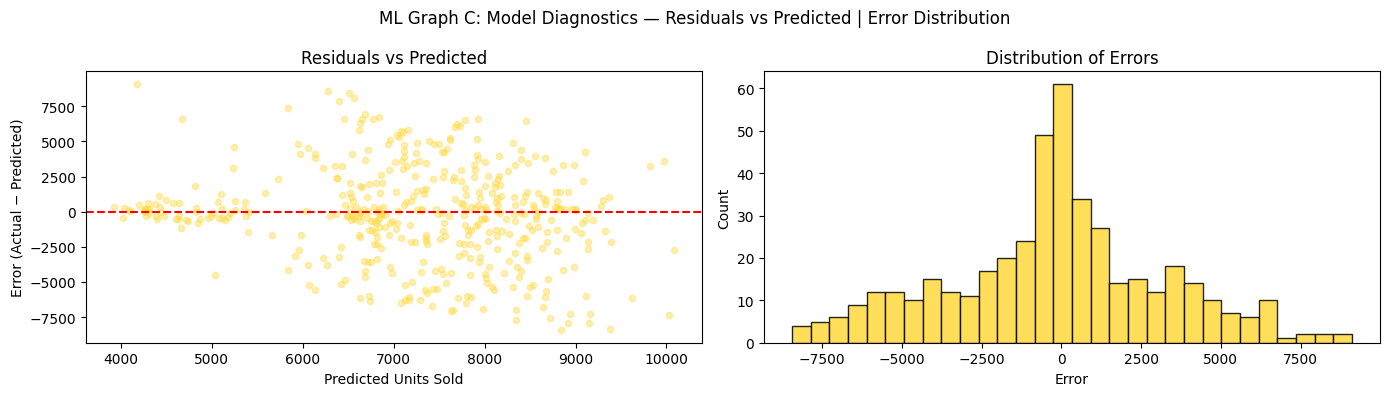

In [ ]:
# ML Graph C — Residuals vs Predicted + Error Histogram

residuals = y_test - preds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ML Graph C: Model Diagnostics — Residuals vs Predicted | Error Distribution", fontsize=12)

axes[0].scatter(preds, residuals, alpha=0.4, color="#FFD93D", s=20)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Units Sold")
axes[0].set_ylabel("Error (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=30, color="#FFD93D", alpha=0.85, edgecolor="black")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Errors")

plt.tight_layout()
plt.show()

<h3><b>🟩 Conclusion </b></h3>

Through systematic ***data cleaning, exploratory analysis, and ML‑based prediction***, this project delivers a ***comparative analysis*** of Maruti Suzuki, Mahindra, and Hyundai in the Indian market. The insights generated can help stakeholders identify ***competitive advantages, anticipate demand shifts, and make data‑driven decisions***. Ultimately, the combination of rigorous preprocessing and advanced ***ML techniques*** ensures that the conclusions are both reliable and actionable.